In [3]:
# from instance_generator import InstanceGenerator
import pandas as pd
import seaborn as sns
from pprint import pprint
import pickle
import osmnx as ox
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp
import json
from names_generator import generate_name

sns.set_theme(context='paper', style='darkgrid')
INDO_CRS = "EPSG:23867"
RES = 250

farmers_df = pd.read_csv('data/farmers.csv')
ints_df = pd.read_csv('data/ints.csv')
mills_df  = pd.read_csv('data/mills.csv')

with open("../FactoredPlatformSolver/data/graph_0-14960_00.pickle", 'rb') as pickle_file:
    G = pickle.load(pickle_file)

G_proj = ox.project_graph(G, to_crs=INDO_CRS)

/var/folders/7_/y4vpj6ln7b90djzq_hscbgyr0000gn/T/ipykernel_14332/1883677674.py:23: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  G = pickle.load(pickle_file)


In [32]:
import pickle
import random
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from pyproj import Transformer
import osmnx as ox
from scipy.special import logsumexp, gammaln
from scipy.interpolate import interp1d
import yaml
import os

# GLOBAL CONSTANTS
INDO_CRS = "EPSG:23867"
LL_CRS = "EPSG:4326"
MIN_CAPACITY, MAX_CAPACITY = 2, 9
RES = 250  
MAX_DIST = 63000

class InstanceGenerator:
    """
    Generates synthetic farmer-intermediary instances using a hybrid 
    Bayesian prior (Gamma + Spatial) with local sequential clustering.
    """
    def __init__(self, farmers_df, ints_df, 
                 graph_path="../FactoredPlatformSolver/data/graph_0-14960_00.pickle"):
        
        # CRS transformers: always_xy=True ensures (Lon, Lat) order
        self.xy_to_ll = Transformer.from_crs(INDO_CRS, LL_CRS, always_xy=True)
        self.ll_to_xy = Transformer.from_crs(LL_CRS, INDO_CRS, always_xy=True)

        self.farmers_df = farmers_df
        self.ints_df = ints_df
        self.G_proj, self.bbox_m = self._load_graph(graph_path)
        
        # 1. Setup Grid
        x_ax = np.arange(self.bbox_m[0], self.bbox_m[2], RES)
        y_ax = np.arange(self.bbox_m[1], self.bbox_m[3], RES)
        gx, gy = np.meshgrid(x_ax, y_ax, indexing='ij')
        self.grid_coords = np.vstack([gx.ravel(), gy.ravel()])

        # 2. Setup Spatial Priors
        self.int_spatial_kde = self._init_int_kde()
        self.farmer_spatial_kde = self._init_farmer_kde()
        
        # Precompute global farmer spatial prior on the grid
        p_spatial = self.farmer_spatial_kde.evaluate(self.grid_coords)
        self.p_spatial = p_spatial / (p_spatial.sum() + 1e-20)

        # 3. Setup Distance Priors (Gamma)
        self.gamma_lookups = self._init_gamma_kdes()

        # 4. Cache Historical Stats
        self.hist_quantities = (self.farmers_df.groupby('int_id')['quantity']
                                .apply(list).to_dict())
        
        counts_df = (self.farmers_df.groupby(['int_id', 'date'])
                    .size().reset_index(name='count'))
        self.hist_n_farmers = counts_df.groupby('int_id')['count'].apply(list).to_dict()

        self.ints = {}
        self.mills = [{'id': 'SKIP', 'location': (-0.682643, 102.501522)}]

        self.sigmas = {'Dodi Lesmana': 2500,
            'Purnomo': 2500,
            'Isna': 4000,
            'Agus Wibowo': 12000,
            'Nurmala': 13500,
            'yaya suhayat': 12500,
            'Agus Yasir': 6500,
            'Ngatinu': 5500,
            'Samsuri': 13000,
            'Riki Mandala': 30500,
            'Syafrial': 9500,
            'Yaman Saragih': 3500,
            'Khairul': 4500,
            'Ndoharo': 2500}

    def _load_graph(self, graph_path):
        with open(graph_path, 'rb') as f:
            G = pickle.load(f)
        G_proj = ox.project_graph(G, to_crs=INDO_CRS)
        nodes_proj, _ = ox.graph_to_gdfs(G_proj)
        return G_proj, nodes_proj.total_bounds

    def _init_int_kde(self):
        coords = self.ints_df.drop_duplicates(['int_id'])[['int_x', 'int_y']].T
        return gaussian_kde(coords, bw_method='scott')

    def _init_farmer_kde(self, farmer_bw=0.2):
        coords = self.farmers_df.drop_duplicates(['farmer_x', 'farmer_y'])[['farmer_x', 'farmer_y']].T
        return gaussian_kde(coords, bw_method=farmer_bw)

    def _init_gamma_kdes(self):
        """Builds lookup tables for the Gamma Mixture distance model."""
        int_to_dists = (self.farmers_df
                        .drop_duplicates(['int_id', 'farmer_x', 'farmer_y'])
                        .groupby('int_id')['distance']
                        .apply(np.array).to_dict())
        
        lookups = {}
        x_eval = np.linspace(0, MAX_DIST + 10000, 2000)
        
        for i_id, dists in int_to_dists.items():
            n = len(dists)
            h = 0.1 * np.mean(dists) + 1e-6
            shape = (dists / h)
            
            pdf_values = np.zeros_like(x_eval)
            for i in range(n):
                s, scale = shape[i], h
                with np.errstate(divide='ignore', invalid='ignore'):
                    # Gamma log-PDF
                    log_pdf = (
                        (s - 1) * np.log(x_eval + 1e-10) 
                        - (x_eval / scale) 
                        - (gammaln(s + 1e-10) + s * np.log(scale))
                    )
                pdf_values += np.exp(log_pdf)
            
            pdf_values /= n
            lookups[i_id] = interp1d(x_eval, pdf_values, fill_value=(0,0), bounds_error=False)
            
        return lookups
    
    def _init_sigmas(self):
        self.sigmas = {int_id: self.find_mle_sigma_adaptive(int_id, 2500, 500) for int_id in self.ints}

    def gen_ints(self, n_ints):
        """Generates intermediary centers within the graph bounding box."""
        ints = {}
        types = list(self.gamma_lookups.keys())
        for i in range(n_ints):
            int_id = generate_name(style='capital')
            int_type = random.choice(types)
            while True:
                sample = self.int_spatial_kde.resample(1).flatten()
                if (self.bbox_m[0] <= sample[0] <= self.bbox_m[2] and 
                    self.bbox_m[1] <= sample[1] <= self.bbox_m[3]):
                    int_xy = sample
                    break
            lon, lat = self.xy_to_ll.transform(int_xy[0], int_xy[1])
            ints[int_id] = {'xy': int_xy, 'll': (lat, lon), 'type': int_type}
        self.ints = ints


    def gen_int_pickups_log(self, int_xy, int_type, n_farmers, sigma=500):
        """Sequential sampling using Log-Base Prior + Gaussian Kernels."""
        dist_lookup = self.gamma_lookups[int_type]
        grid_points = self.grid_coords.T 
        dists = np.linalg.norm(grid_points - int_xy, axis=1)
        
        # 1. Base Prior (Distance PDF * Spatial Density)
        p_dist_raw = dist_lookup(dists)
        log_p_base = np.log(p_dist_raw + 1e-20) + np.log(self.p_spatial + 1e-20)
        log_p_base -= logsumexp(log_p_base)

        locs = []
        sigma_sq_2 = 2 * (sigma**2)
        acc_exp_kernels = np.zeros(len(grid_points))

        for k in range(n_farmers):
            if k == 0:
                log_p_cond = log_p_base
            else:
                # Add clustering influence (Product in linear, Add in log)
                # log_local_factor = np.log(acc_exp_kernels + 1e-20)
                log_local_factor = np.log(acc_exp_kernels + 1e-20) - np.log(k)
                log_p_cond = log_p_base + log_local_factor
                log_p_cond -= logsumexp(log_p_cond)

            p_sampling = np.exp(log_p_cond)
            
            # Robustness fallback
            if np.isnan(p_sampling).any() or p_sampling.sum() == 0:
                p_sampling = self.p_spatial

            idx = np.random.choice(len(p_sampling), p=p_sampling/p_sampling.sum())
            sampled_xy = self.grid_coords[:, idx]
            locs.append(sampled_xy)
            
            # Efficient O(N_grid) KDE update
            new_dist_sq = np.sum((grid_points - sampled_xy)**2, axis=1)
            acc_exp_kernels += np.exp(-new_dist_sq / sigma_sq_2)

        qs = np.random.choice(self.hist_quantities[int_type], size=n_farmers, replace=True)
        return np.array(locs), qs

    def gen_instance(self, instance_id):
        """Orchestrates full instance generation."""
        farmers, ints = [], []

        for int_id, int_data in self.ints.items():
            int_type, int_xy, int_ll = int_data['type'], int_data['xy'], int_data['ll']
            n_farmers = np.random.choice(self.hist_n_farmers[int_type])
            
            if n_farmers > 0:
                # Get the specific sigma for this intermediary type
                s_val = self.sigmas[int_type]
                locs, qs = self.gen_int_pickups_log(int_xy, int_type, n_farmers, s_val)

                total_q = qs.sum()

                print(f'total q: {total_q}')
                if total_q >= MAX_CAPACITY:
                    print(f'max exceeded, rescaling...')
                    sf = (MAX_CAPACITY - 0.01) / total_q
                elif total_q < MIN_CAPACITY:
                    print('min not met, rescaling...')
                    sf = MIN_CAPACITY / total_q
                else:
                    sf = 1

                qs_scaled = qs * sf
                print(f'final q: {qs_scaled.sum()}')
                print()
                
                routes = []
                for f in range(n_farmers):
                    f_id = f'{int_id}_f{f}'
                    f_lon, f_lat = self.xy_to_ll.transform(locs[f][0], locs[f][1])
                    
                    farmers.append({
                        'id': f_id, 
                        'location': (f_lat, f_lon), # Store as (Lat, Lon)
                        'quantity': float(qs_scaled[f])
                    })
                    routes.append(f_id)

                ints.append({
                    'id': int_id, 
                    'capacity': MAX_CAPACITY, 
                    'location': int_ll, 
                    'routes': routes
                })

        instance = {'farmers': farmers, 'intermediaries': ints, 'mills': self.mills}

        os.makedirs("instances", exist_ok=True)
        with open(f'instances/{instance_id}.yaml', 'w') as file:
            yaml.dump(instance, file, default_flow_style=False)    
    

    def find_mle_sigma_adaptive(self, int_type, start_sigma=1000, step=100):
        """
        Finds the optimal sigma by climbing the likelihood surface 
        until results begin to worsen.
        """
        best_sigma = start_sigma
        best_ll = -np.inf
        current_sigma = start_sigma
        
        # Precompute log_p_base (Base Prior: Distance * Spatial)
        int_data = self.ints_df[self.ints_df['int_id'] == int_type].iloc[0]
        int_xy = np.array([int_data['int_x'], int_data['int_y']])
        dists = np.linalg.norm(self.grid_coords.T - int_xy, axis=1)
        
        log_p_base = np.log(self.gamma_lookups[int_type](dists) + 1e-20) + np.log(self.p_spatial + 1e-20)
        
        # Get historical daily routes
        daily_groups = self.farmers_df[self.farmers_df['int_id'] == int_type].groupby('date')
        historical_indices = []
        
        # Pre-map historical farmers to grid indices to save time in the loop
        for _, group in daily_groups:
            coords = group[['farmer_x', 'farmer_y']].values
            indices = [np.argmin(np.sum((self.grid_coords.T - c)**2, axis=1)) for c in coords]
            historical_indices.append(indices)

        while True:
            total_ll = 0
            sigma_sq_2 = 2 * (current_sigma**2)
            
            for f_indices in historical_indices:
                acc_exp_kernels = np.zeros(len(self.grid_coords[0]))
                
                for k, target_idx in enumerate(f_indices):
                    # Conditional Log-Prob
                    if k == 0:
                        log_p_cond = log_p_base
                    else:
                        # log_local_factor = np.log(acc_exp_kernels + 1e-20)
                        log_local_factor = np.log(acc_exp_kernels + 1e-20) - np.log(k)
                        log_p_cond = log_p_base + log_local_factor
                    
                    log_p_cond -= logsumexp(log_p_cond)
                    total_ll += log_p_cond[target_idx]
                    
                    # Update kernels
                    sampled_xy = self.grid_coords[:, target_idx]
                    dist_sq = np.sum((self.grid_coords.T - sampled_xy)**2, axis=1)
                    acc_exp_kernels += np.exp(-dist_sq / sigma_sq_2)
            
            # Termination logic: If likelihood drops, the previous sigma was the peak
            if total_ll > best_ll:
                best_ll = total_ll
                best_sigma = current_sigma
                current_sigma += step
            else:
                break # Peak found
                
        return best_sigma

In [33]:
ig = InstanceGenerator(farmers_df, ints_df)

ig.gen_ints(5)

ig.ints

/var/folders/7_/y4vpj6ln7b90djzq_hscbgyr0000gn/T/ipykernel_14332/3550230710.py:81: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  G = pickle.load(f)


{'Cranky Haslett': {'xy': array([888084.75150759, -77257.89345877]),
  'll': (-0.6976743457221327, 102.48571045984048),
  'type': 'Ndoharo'},
 'Eager Panini': {'xy': array([889863.16735778, -54772.15418661]),
  'll': (-0.4946094485720386, 102.5015354875169),
  'type': 'Khairul'},
 'Stoic Pasteur': {'xy': array([880117.71970695, -49483.18246527]),
  'll': (-0.44688990231582204, 102.41408964194967),
  'type': 'Samsuri'},
 'Bold Merkle': {'xy': array([882388.86600775, -43458.17087147]),
  'll': (-0.3924687505560577, 102.43444003030714),
  'type': 'Samsuri'},
 'Crazy Lewin': {'xy': array([885534.42564422, -65574.63447481]),
  'll': (-0.5921836868296243, 102.46276065941728),
  'type': 'Syafrial'}}

In [45]:
for i in range(10):
    ig.gen_instance(i)

total q: 4.5
final q: 4.5

total q: 3.8
final q: 3.8

total q: 0.8
min not met, rescaling...
final q: 2.0

total q: 2.0
final q: 2.0

total q: 4.3
final q: 4.3

total q: 1.4
min not met, rescaling...
final q: 2.0

total q: 0.7
min not met, rescaling...
final q: 2.0

total q: 1.0
min not met, rescaling...
final q: 2.0

total q: 2.0
final q: 2.0

total q: 3.2
final q: 3.2

total q: 8.7
final q: 8.7

total q: 0.8
min not met, rescaling...
final q: 2.0

total q: 1.0
min not met, rescaling...
final q: 2.0

total q: 2.0
final q: 2.0

total q: 0.7
min not met, rescaling...
final q: 2.0

total q: 3.9
final q: 3.9

total q: 6.8
final q: 6.8

total q: 2.0
final q: 2.0

total q: 2.0
final q: 2.0

total q: 2.2
final q: 2.2

total q: 2.0
final q: 2.0

total q: 2.8000000000000003
final q: 2.8000000000000003

total q: 2.0
final q: 2.0

total q: 2.0
final q: 2.0

total q: 2.6
final q: 2.6

total q: 3.1
final q: 3.1

total q: 1.0
min not met, rescaling...
final q: 2.0

total q: 0.6
min not met, rescali

### Bootstrap dataset

In [10]:
def instance_to_dfs(instance):
    # Process Farmers
    df_farmers = pd.DataFrame(instance['farmers'])
    df_farmers['farmer_lat'] = df_farmers['location'].apply(lambda x: x[0])
    df_farmers['farmer_lon'] = df_farmers['location'].apply(lambda x: x[1])
    df_farmers['farmer_x'], df_farmers['farmer_y'] = ig.ll_to_xy.transform(
        df_farmers.farmer_lon.values, df_farmers.farmer_lat.values)
    
    df_farmers.drop('location', axis=1)

    # Add a column to identify which intermediary they belong to
    df_farmers['int_id'] = df_farmers['id'].apply(lambda x: x.split('_')[0])

    # Process Intermediaries
    df_ints = pd.DataFrame(instance['intermediaries'])
    df_ints['int_lat'] = df_ints['location'].apply(lambda x: x[0])
    df_ints['int_lon'] = df_ints['location'].apply(lambda x: x[1])
    df_ints['int_x'], df_ints['int_y'] = ig.ll_to_xy.transform(
        df_ints.int_lon.values, df_ints.int_lat.values)
    
    df_ints.drop('location', axis=1)

    df_combined = df_farmers.merge(df_ints, how='left', left_on='int_id', right_on='id')

    df_combined['distance'] = np.sqrt((df_combined.farmer_x - df_combined.int_x) ** 2 + (df_combined.farmer_y - df_combined.int_y) ** 2)
    
    return df_combined

def enforce_capacity(df, max_cap=MAX_CAPACITY, min_cap=MIN_CAPACITY):
    # Calculate the current daily sum for every farmer's group
    # Using transform keeps the index aligned with the original dataframe
    group_totals = df.groupby(['int_id', 'date'])['quantity'].transform('sum')
    
    # 1. Handle the Ceiling: total_q > MAX_CAPACITY
    # We use (max_cap - 0.01) to mirror your generator's safety margin
    over_mask = group_totals > max_cap
    if over_mask.any():
        sf_over = (max_cap - 1e-2) / group_totals
        df.loc[over_mask, 'quantity'] *= sf_over[over_mask]
    
    # Recalculate totals after ceiling adjustment for the floor logic
    group_totals = df.groupby(['int_id', 'date'])['quantity'].transform('sum')
    
    # 2. Handle the Floor: total_q < MIN_CAPACITY
    under_mask = group_totals < min_cap
    if under_mask.any():
        sf_under = min_cap / group_totals
        df.loc[under_mask, 'quantity'] *= sf_under[under_mask]
        
    return df

In [11]:
def compute_perturbations(group, period=14):
    dates = group['date'].values.astype('datetime64[D]')
    t = (dates - dates[0]).astype(int)

    # estimate cycle indices
    n = np.round(t / period).astype(int)

    # compute phase: t = phi + 14n -> phi = t - 14n
    phi = int(np.round(np.median(t - period * n)))

    # compute perturbation
    epsilon = t - (phi + period * n)
    out = group.copy()
    out['epsilon'] = epsilon
    return out


df_3 = farmers_df.copy()
df_3['date'] = pd.to_datetime(df_3['date'])
df_3.sort_values(['int_id', 'farmer_x', 'farmer_y', 'date'], inplace=True)

pert_hist = (
    df_3
    .groupby(['int_id', 'farmer_x', 'farmer_y'], group_keys=True)
    .apply(compute_perturbations)
    .reset_index() # Converts group keys back into columns
)

eps = pert_hist['epsilon']

N_CYCLES = 5
HARVEST_CYCLE = 10 # Days in one full rotation

# 1. Generate the base 14-day "Spatial Skeleton"
# base_dfs = []
# for k in range(HARVEST_CYCLE):
#     instance = ig.gen_instance(ig.sigmas)
#     df = instance_to_dfs(instance)
#     df['date'] = k
#     base_dfs.append(df)

# base_df = pd.concat(base_dfs)

# 2. Extend to N_CYCLES
all_cycles = []

for k in range(HARVEST_CYCLE * N_CYCLES):
    instance = ig.gen_instance(ig.sigmas)
    df = instance_to_dfs(instance)
    df['date'] = k
    all_cycles.append(df)


# for cycle in range(N_CYCLES):
#     temp_df = base_df.copy()
    
#     # Shift the date based on which cycle we are in
#     # Cycle 0: 0-13, Cycle 1: 14-27, etc.
#     temp_df['date'] = temp_df['date'] 
#     # temp_df['date'] = temp_df['date'] + (cycle * HARVEST_CYCLE)
    
#     # 3. Sample day perturbations from 'eps'
#     # 'eps' should be a list like [-1, 0, 1, 0, 2]
#     # perturbations = np.random.choice(eps, size=len(temp_df))
#     # temp_df['date'] = temp_df['date'] + perturbations
    
#     all_cycles.append(temp_df)

# Final formatting
df = pd.concat(all_cycles)
df = enforce_capacity(df)

df.sort_values(by=['int_id', 'date'], inplace=True)
df.rename(columns={'id': 'farmer_id'}, inplace=True)

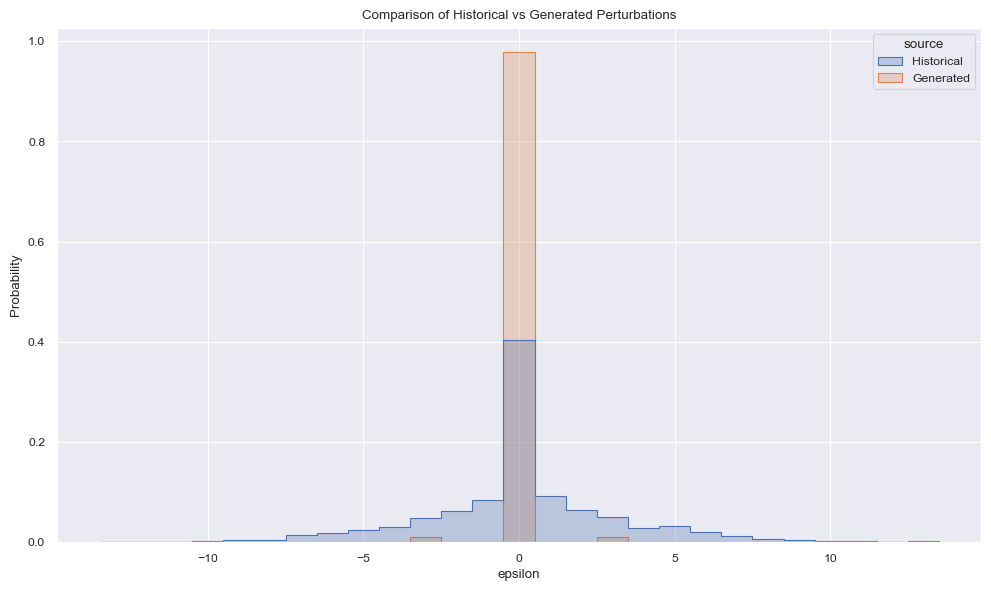

In [12]:
df_3 = farmers_df.copy()
df_3['date'] = pd.to_datetime(df_3['date'])
df_3.sort_values(['int_id', 'farmer_x', 'farmer_y', 'date'], inplace=True)

# 1. Compute perturbations and flatten the resulting index immediately
pert_hist = (
    df_3
    .groupby(['int_id', 'farmer_x', 'farmer_y'], group_keys=True)
    .apply(compute_perturbations)
    .reset_index() # Converts group keys back into columns
)
pert_hist['source'] = 'Historical'

pert_gen = (
    df
    .groupby(['int_id', 'farmer_x', 'farmer_y'], group_keys=True)
    .apply(compute_perturbations)
    .reset_index()
)
pert_gen['source'] = 'Generated'

pert_hist_df = pert_hist.reset_index()
pert_gen_df = pert_gen.reset_index()

# 2. Add source labels
pert_hist_df['source'] = 'Historical'
pert_gen_df['source'] = 'Generated'

# 3. Combine
df_combined = pd.concat([pert_hist_df, pert_gen_df], ignore_index=True)

# 4. Plotting
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_combined, 
    x='epsilon', 
    hue='source', 
    discrete=True,      # Keeps bins aligned to integers
    alpha=0.3,         # Sets transparency for the fill
    element="step",    # 'step' or 'poly' helps distinguish overlapping areas
    common_norm=False,  # Normalizes each source independently if volumes differ
    stat='probability'
)

plt.title("Comparison of Historical vs Generated Perturbations")
plt.tight_layout()
plt.show()

### How many farmers are in each intermediary's network?

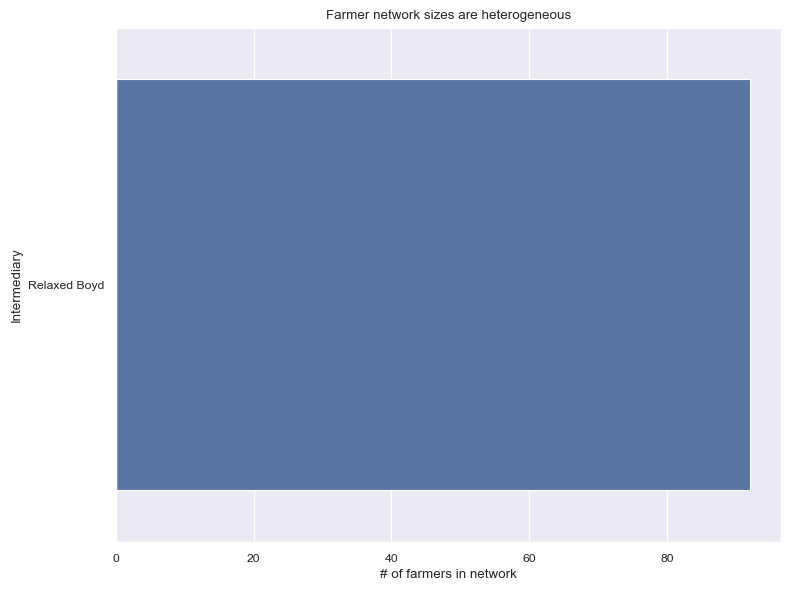

In [13]:
df_1 = df.copy()
res_1 = df_1.drop_duplicates(['int_id', 'farmer_x', 'farmer_y']).groupby('int_id').size()
res_1.sort_values(inplace=True, ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=res_1.values, y=res_1.index)

plt.ylabel('Intermediary')
plt.xlabel('# of farmers in network')
plt.title('Farmer network sizes are heterogeneous')

plt.tight_layout()
plt.show()

### Verify: n_farmers matches (by type)

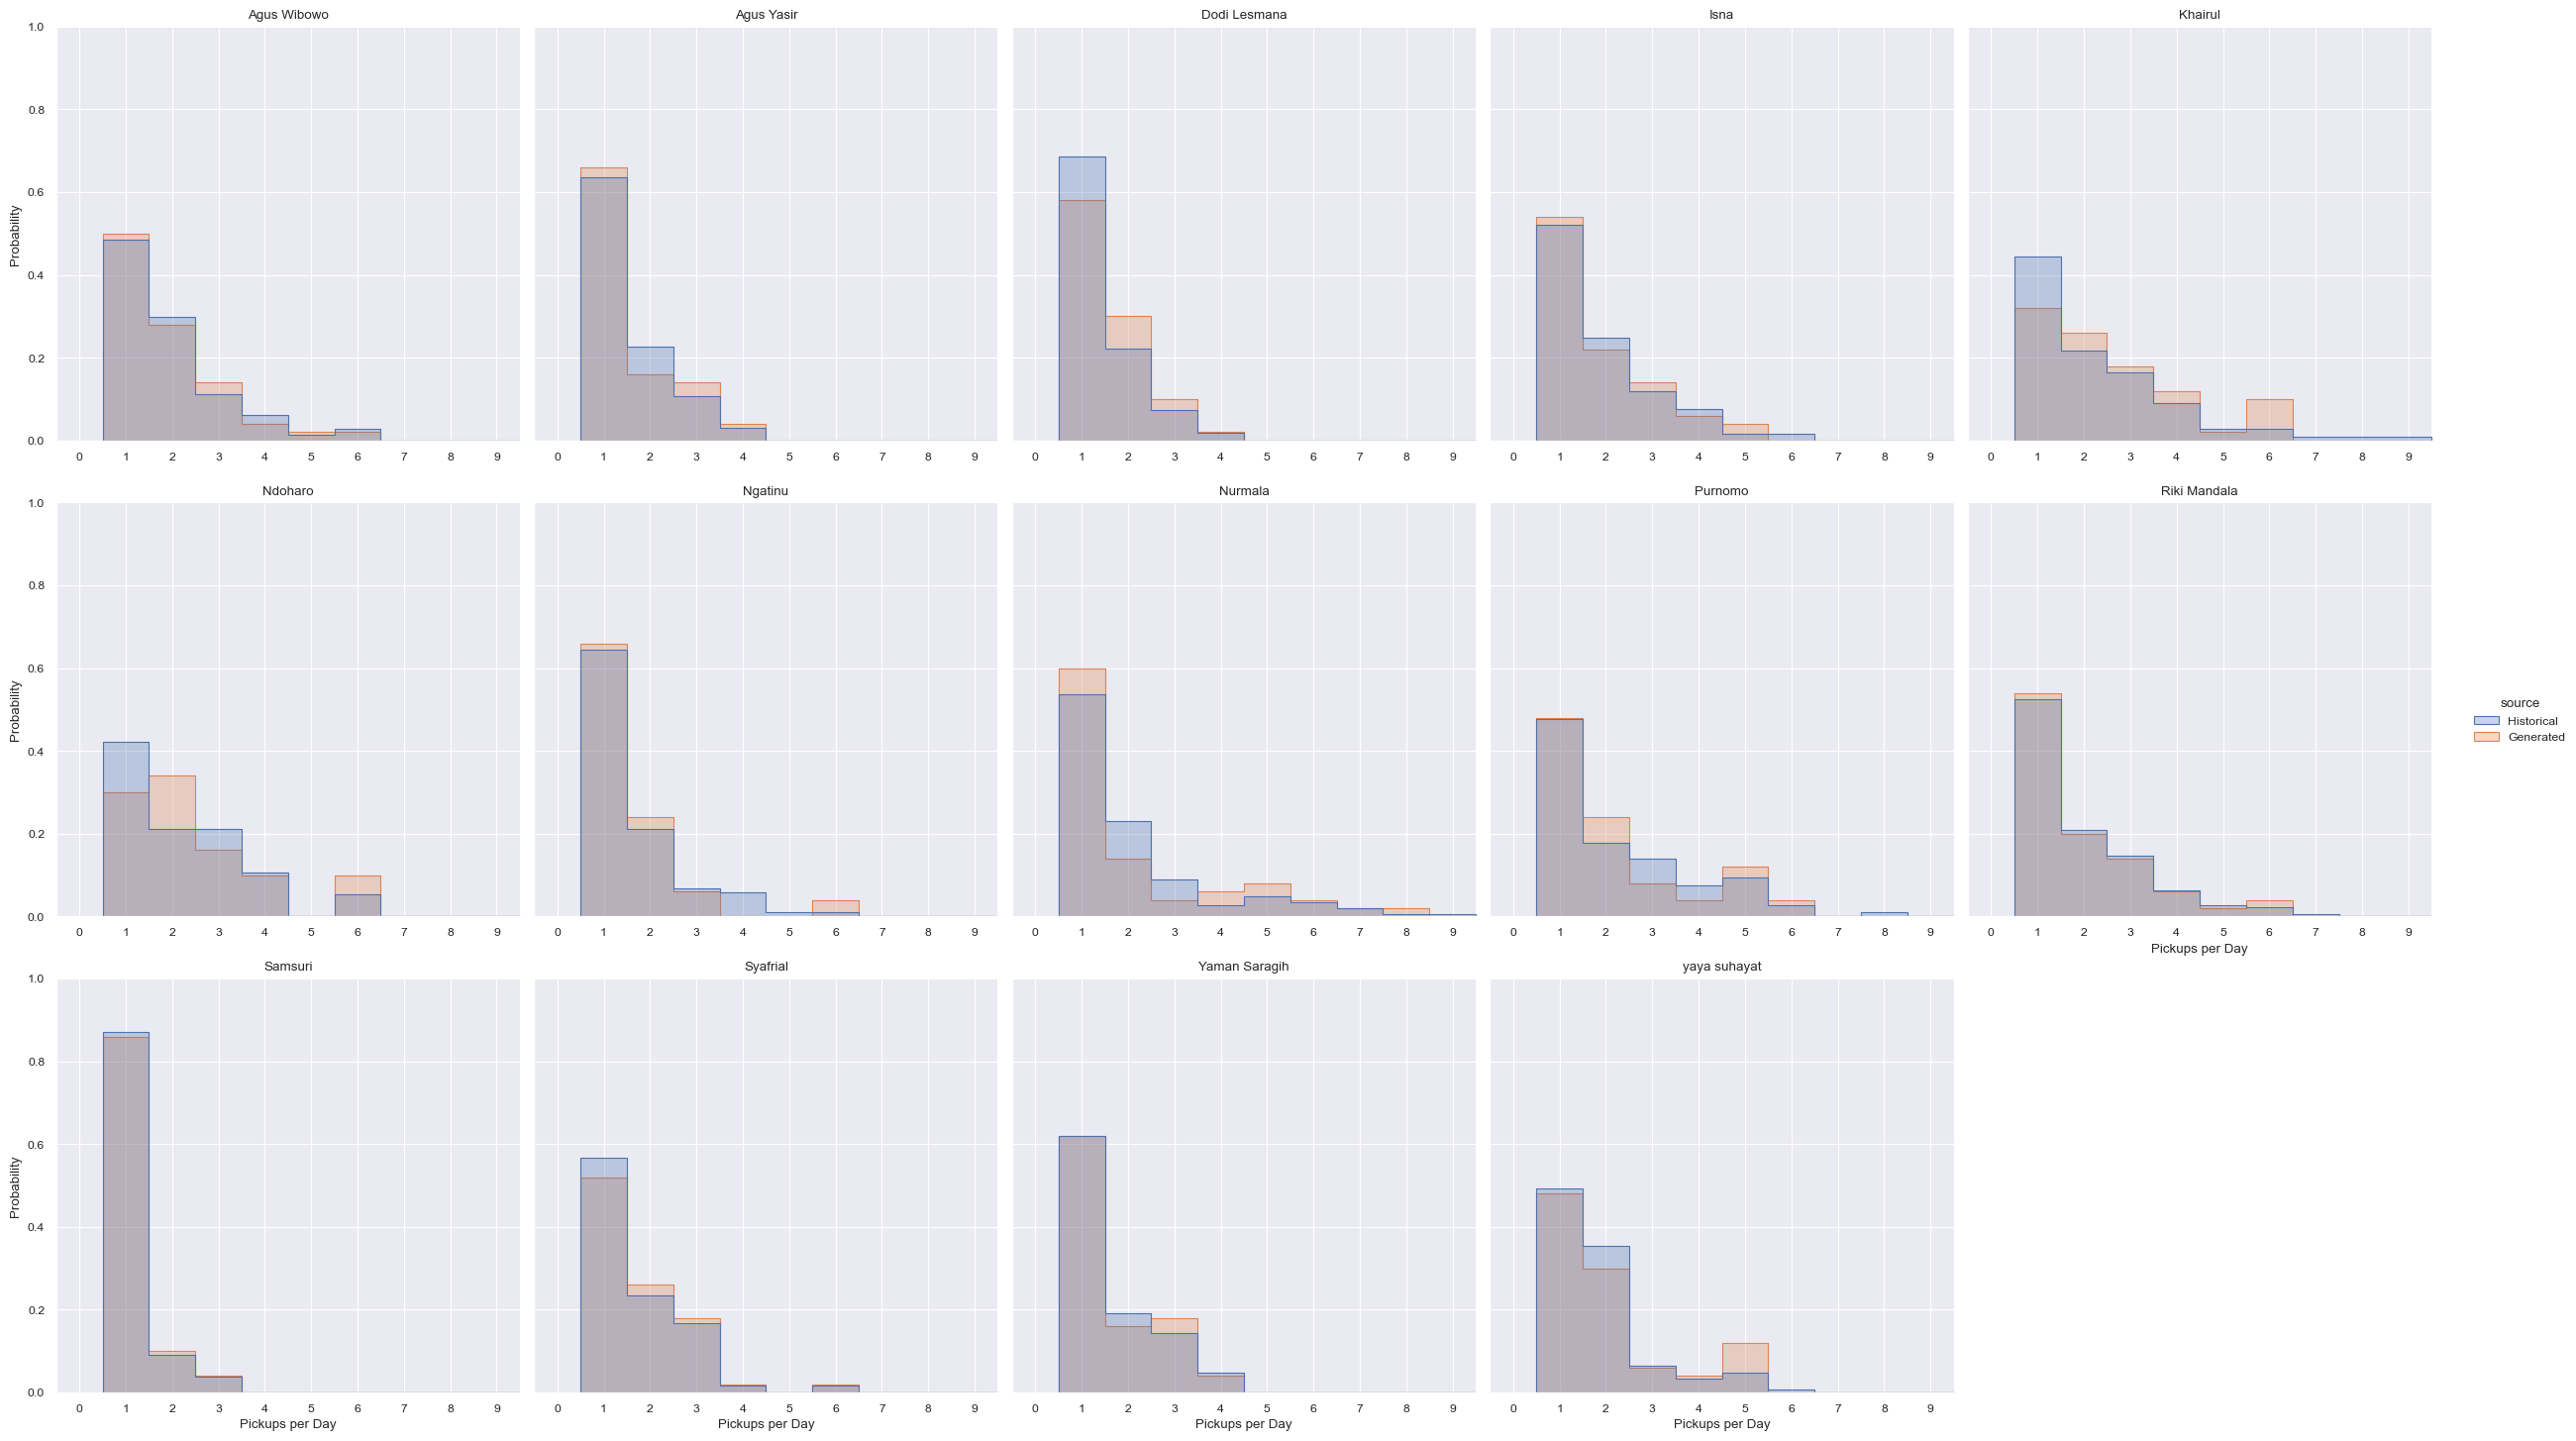

In [11]:
pickups_hist = farmers_df.groupby(['int_id', 'date']).size().reset_index(name='count')
pickups_hist['source'] = 'Historical'

pickups_gen = df.groupby(['int_id', 'date']).size().reset_index(name='count')
pickups_gen['source'] = 'Generated'

df_combined = pd.concat([pickups_hist, pickups_gen], ignore_index=True)

max_count = df_combined['count'].max()
bins = np.arange(-0.5, max_count + 1.5, 1)

g = sns.displot(
    data=df_combined,
    x='count',
    hue='source',          # This creates the overlay
    col='int_id',
    col_wrap=5,
    bins=bins,
    discrete=True,
    stat='probability',
    common_norm=False,     # Ensures each source's bars sum to 1 within the facet
    element='step',        # 'step' makes overlays much easier to read
    alpha=0.3,             # Transparency for the fill
    facet_kws={
        'sharex': True,
        'sharey': True
    }
)

xticks = np.arange(0, max_count + 1)
for ax in g.axes.flatten():
    ax.set_xticks(xticks)
    ax.set_xlim(-0.5, max_count + 0.5)
    ax.tick_params(labelbottom=True)

g.set(ylim=(0, 1))
g.set_titles("{col_name}")
g.figure.subplots_adjust(hspace=0.15)
g.set_axis_labels("Pickups per Day", "Probability")

# g.figure.suptitle('Distribution of # of farmers picked up (by intermediary)', fontsize=14)
g.figure.subplots_adjust(top=0.955)

plt.show()

### Verify: quantity distributions match (by type)

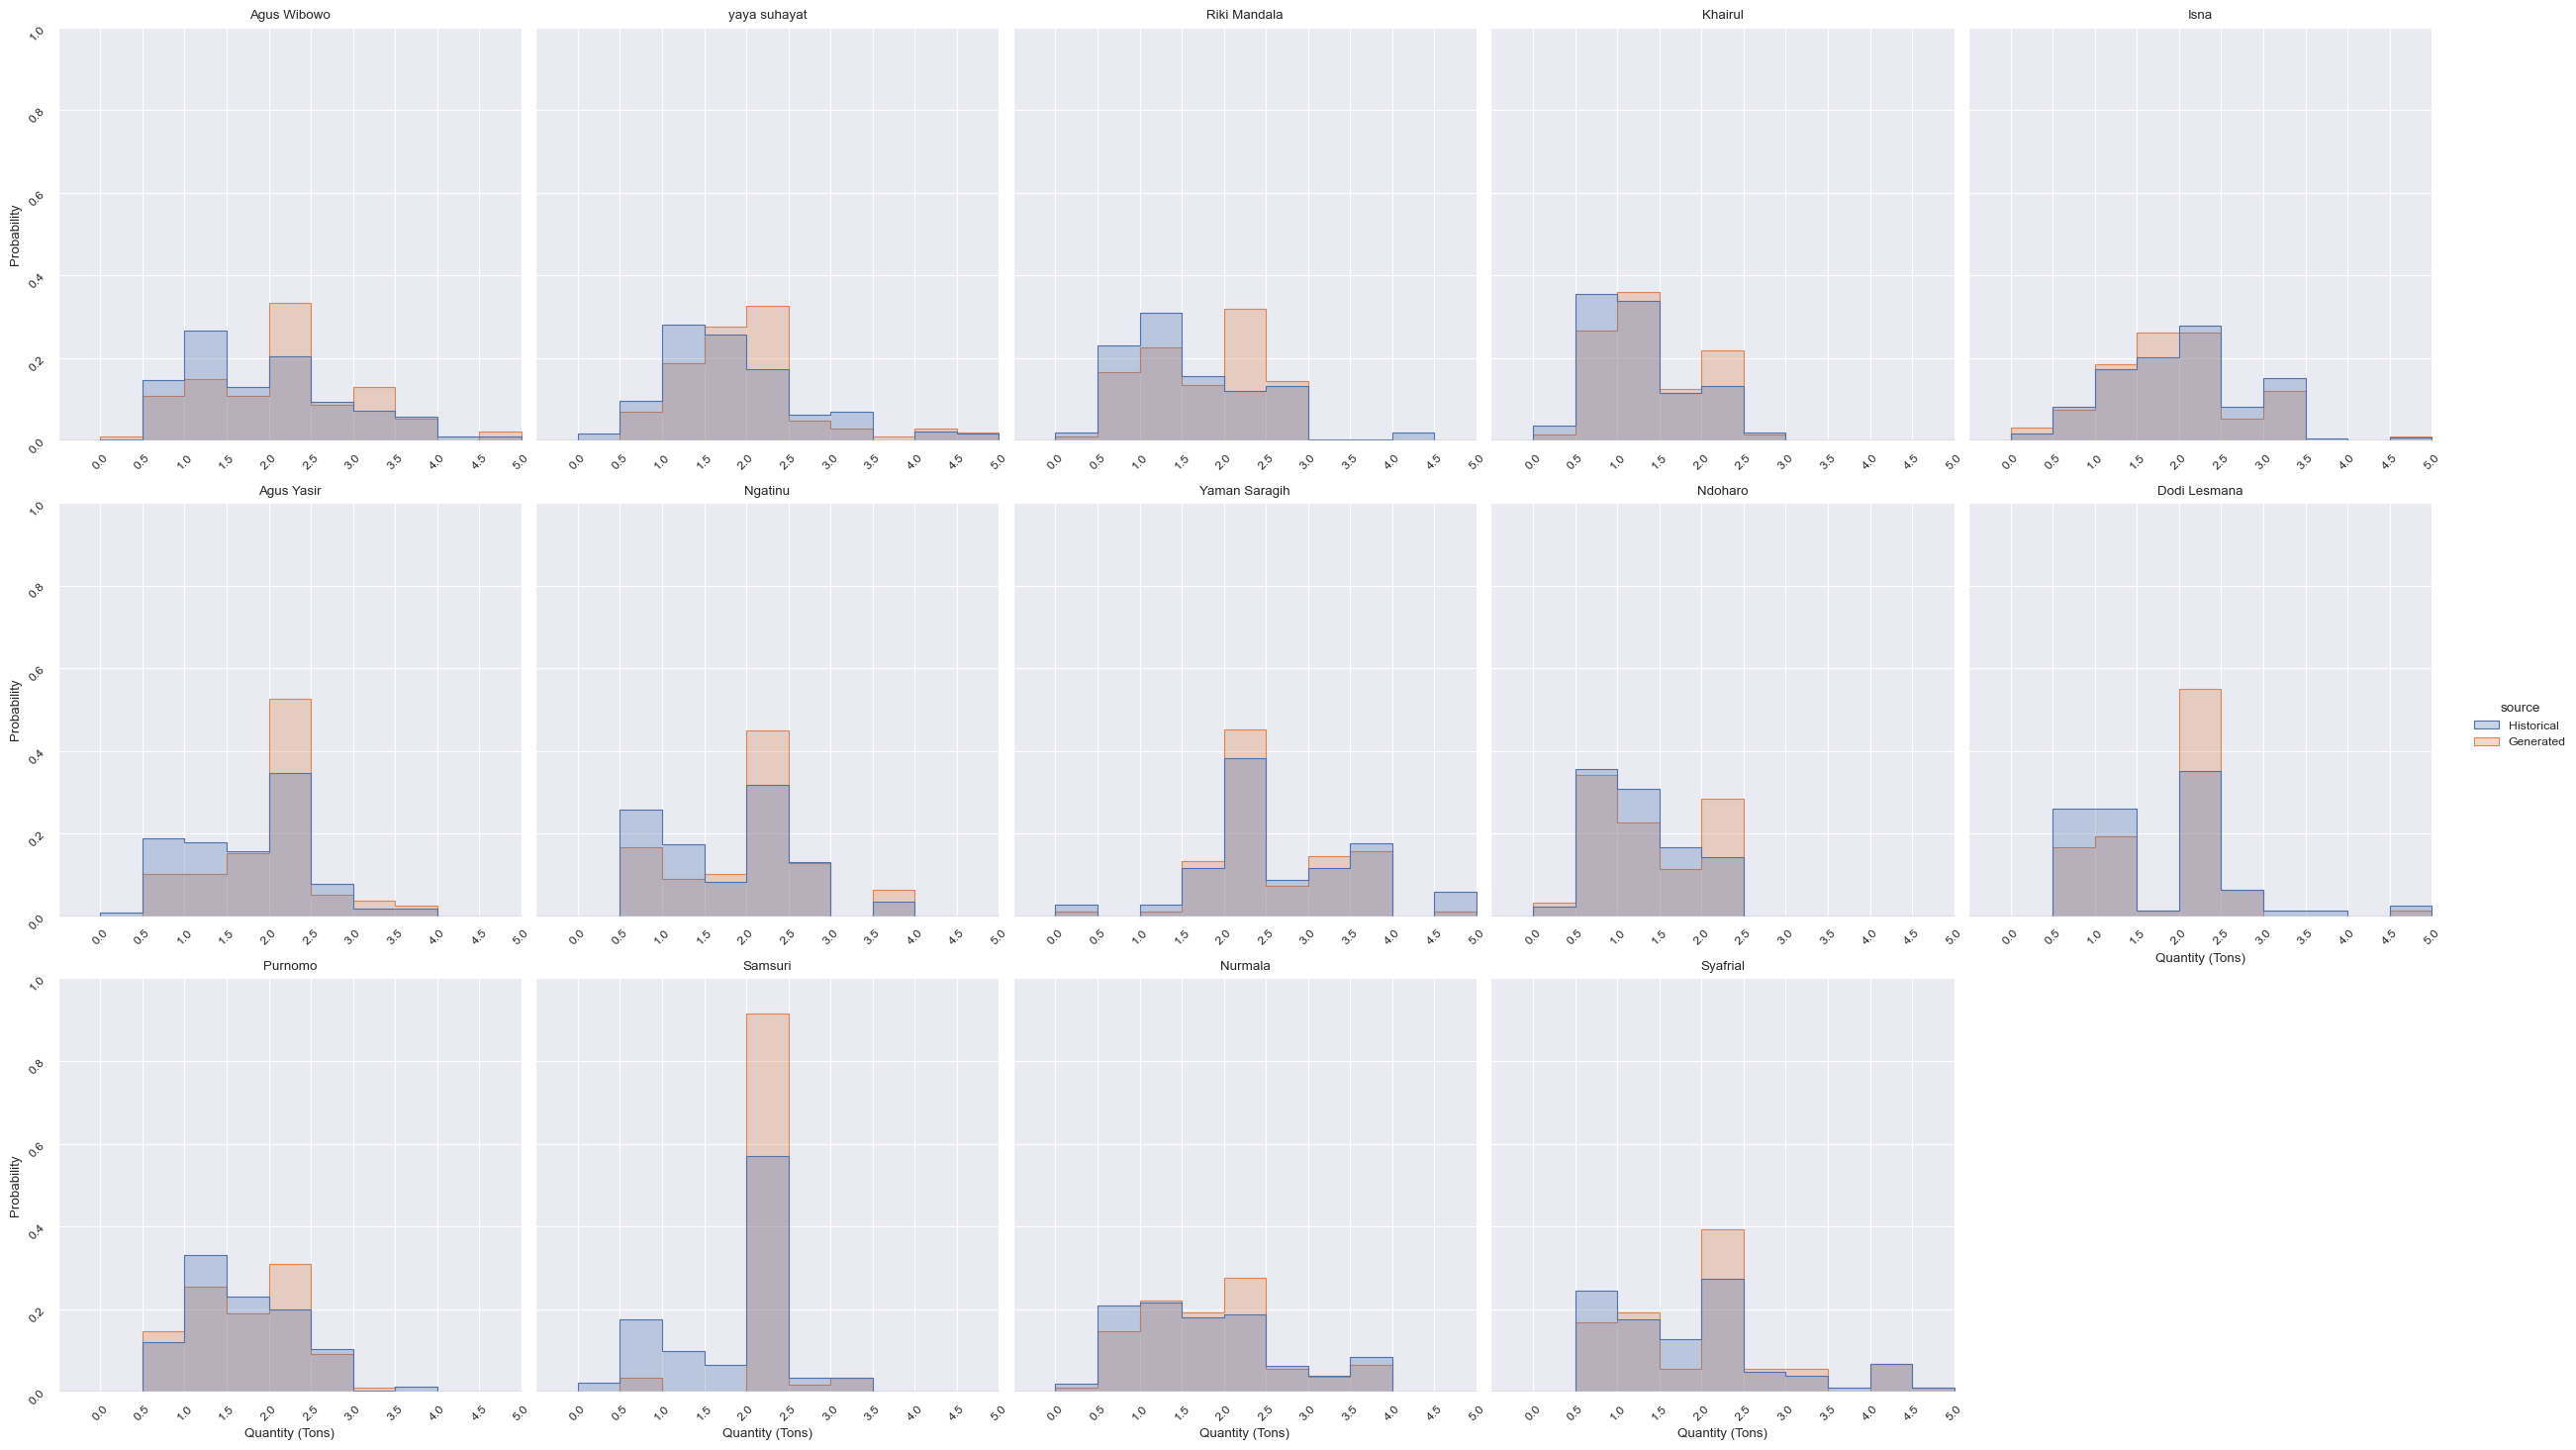

In [12]:
# 1. Prepare the two datasets
df_hist = farmers_df[['int_id', 'quantity']].copy()
df_hist['source'] = 'Historical'

df_gen = df[['int_id', 'quantity']].copy()
df_gen['source'] = 'Generated'

# 2. Combine them
df_combined = pd.concat([df_hist, df_gen], ignore_index=True)

# 3. Define Bins (shared for both)
max_q = df_combined['quantity'].max()
bins = np.arange(-0.5, max_q + 1.5, 0.5)

# 4. Plot using displot
g = sns.displot(
    data=df_combined,
    x='quantity',
    hue='source',
    col='int_id',
    col_wrap=5,
    bins=bins,
    stat='probability',
    common_norm=False,
    element='step',       # Highly recommended for overlays
    alpha=0.3,
    facet_kws={
        'sharex': True,
        'sharey': True
    }
)

# 5. Axis Formatting
xticks = np.arange(0, max_q + 1, 0.5)
for ax in g.axes.flatten():
    ax.set_xticks(xticks)
    ax.set_xlim(-0.5, max_q + 0.5)
    ax.tick_params(labelbottom=True, rotation=45) # Rotate for readability

g.set(ylim=(0, 1))
g.set_titles("{col_name}")
g.set_axis_labels("Quantity (Tons)", "Probability")

g.figure.subplots_adjust(hspace=0.15)

# g.figure.suptitle('Distribution of quantity (by intermediary)', fontsize=14)
g.figure.subplots_adjust(top=0.955)
plt.show()

### Verify farmer-intermediary distances match

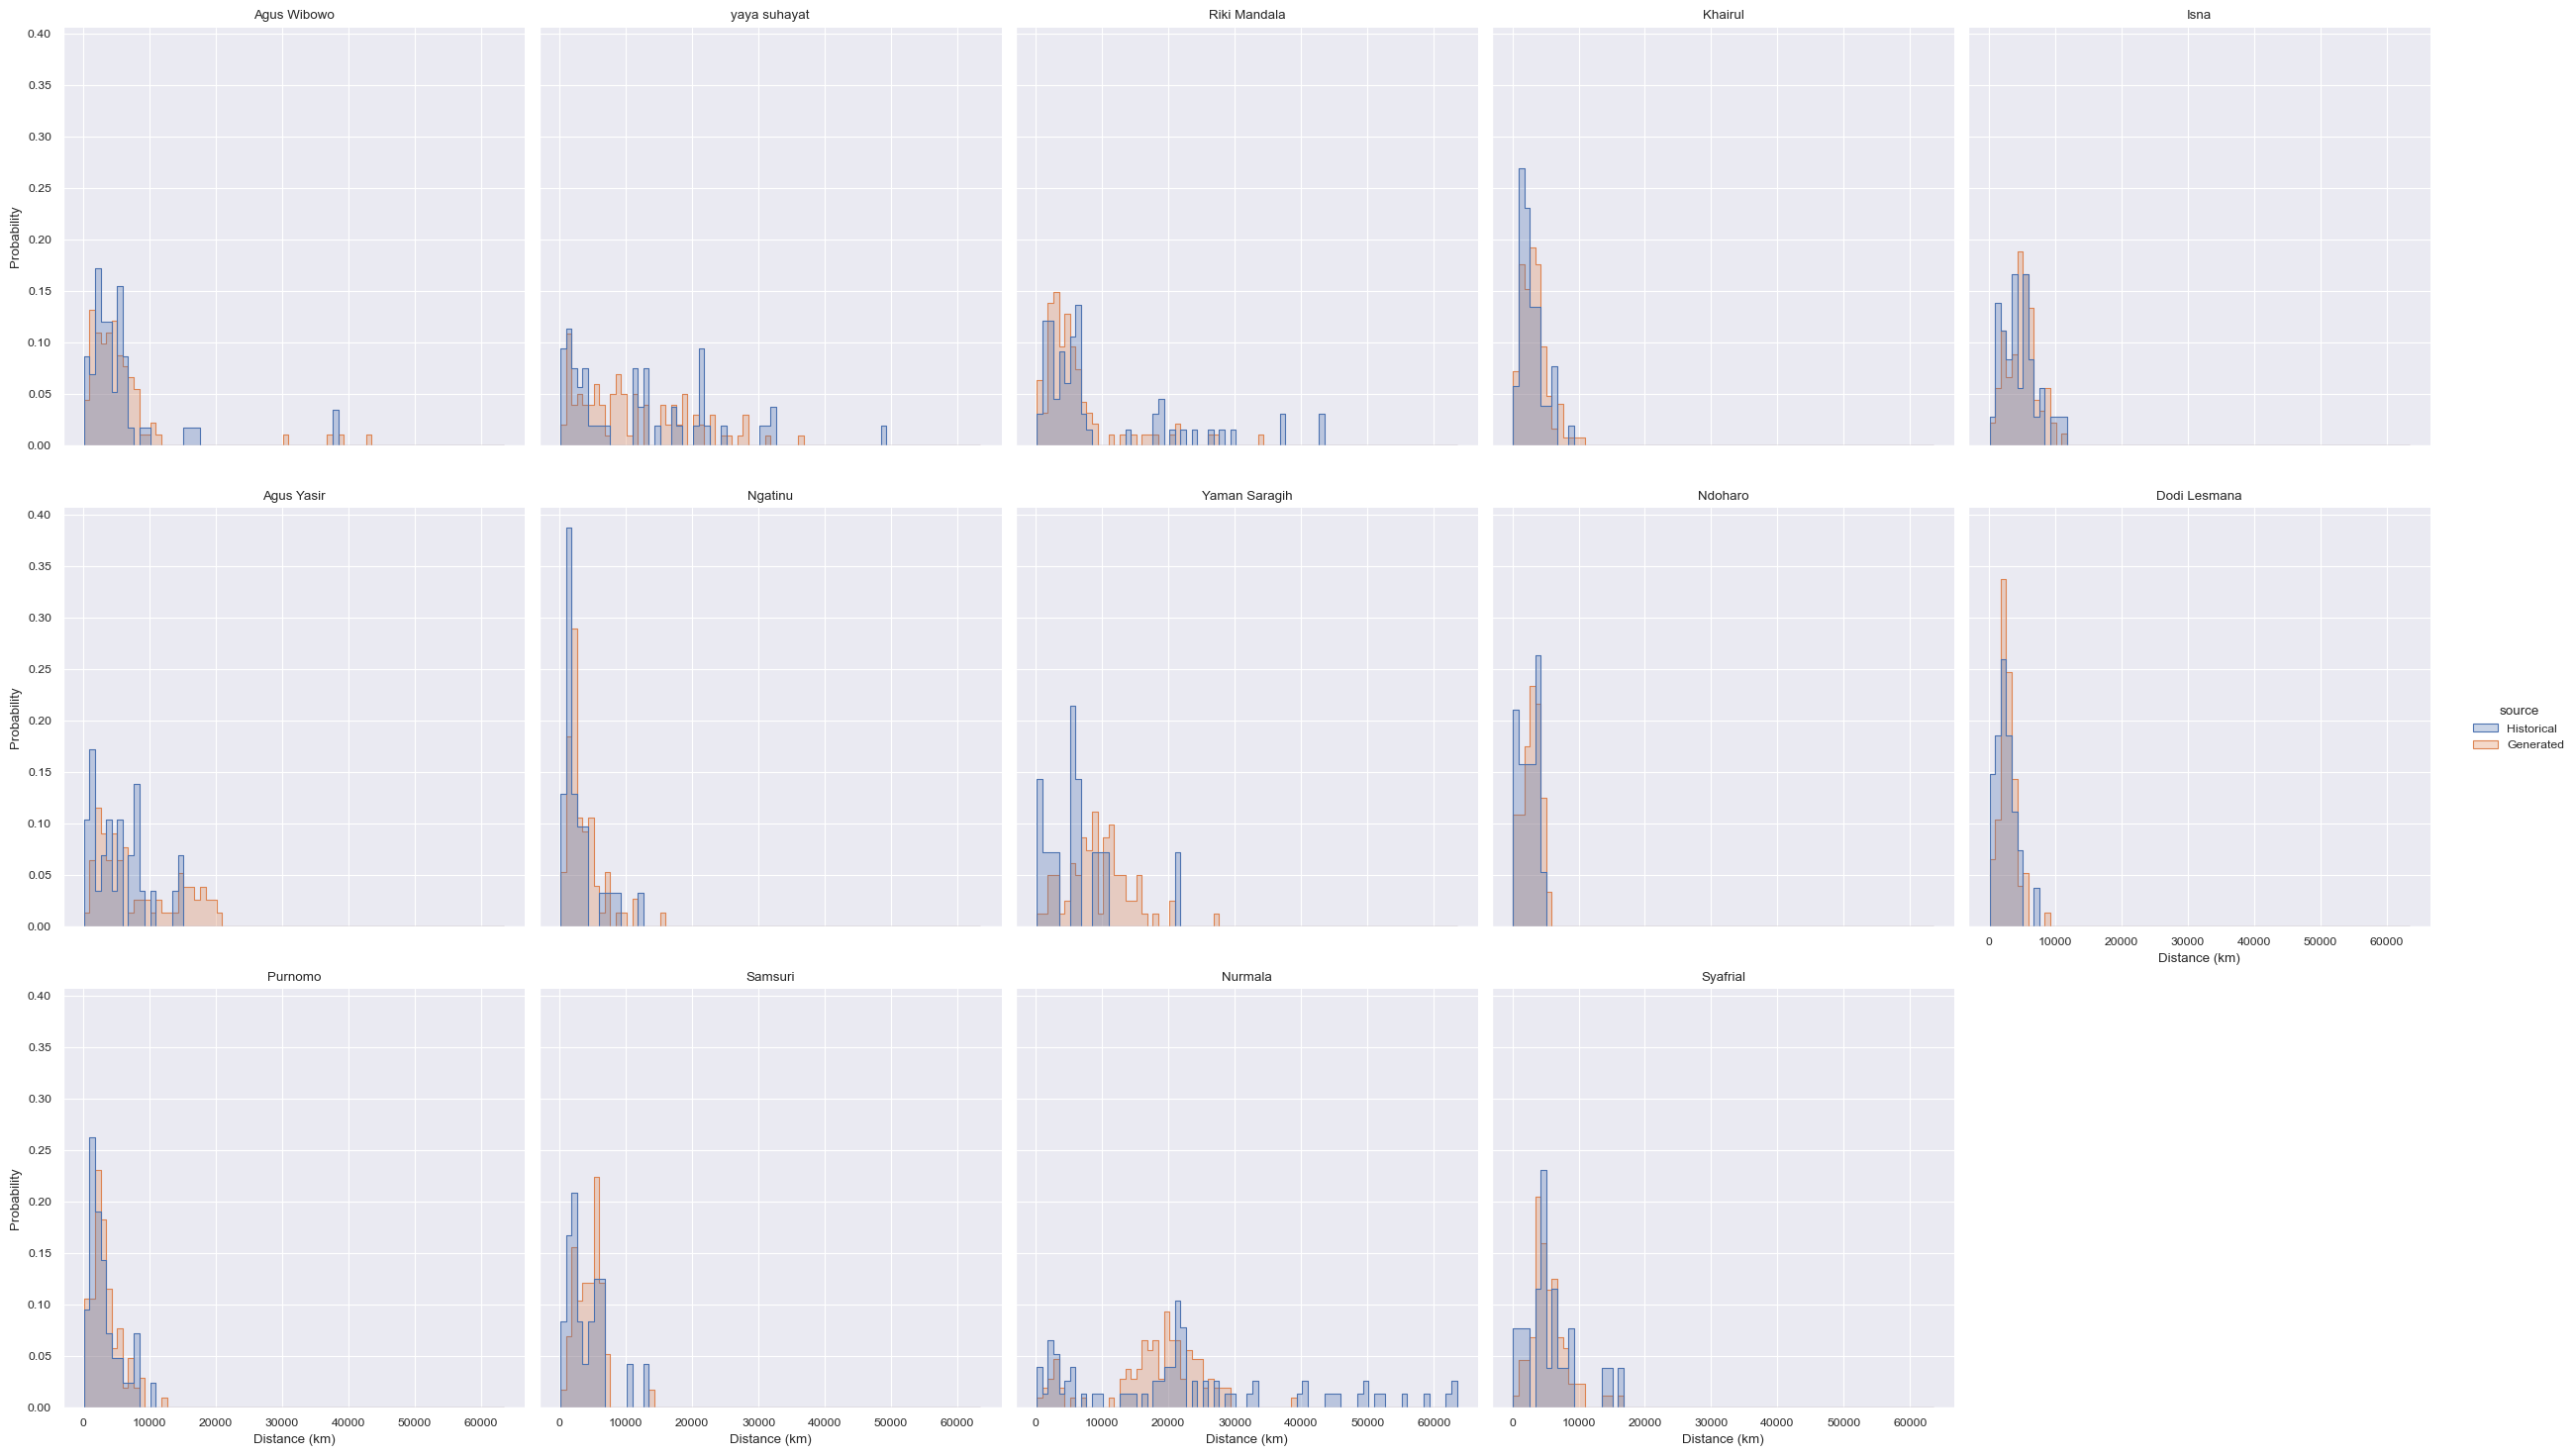

In [13]:
dist_hist = farmers_df.drop_duplicates(['int_id', 'farmer_x', 'farmer_y'])
dist_hist['source'] = 'Historical'

dist_gen = df.drop_duplicates(['int_id', 'farmer_x', 'farmer_y'])
dist_gen['source'] = 'Generated'

df_combined = pd.concat([dist_hist, dist_gen], ignore_index=True)


g = sns.displot(
    data=df_combined,
    x='distance',
    hue='source',
    col='int_id',
    col_wrap=5,
    stat='probability',
    common_norm=False,
    element='step',
    alpha=0.3,
    facet_kws={'sharex': True, 'sharey': True}
)

g.set_axis_labels("Distance (km)", "Probability")
g.set_titles("{col_name}")

g.figure.subplots_adjust(hspace=0.15)

# g.figure.suptitle('Distribution of farmer-intermediary distances', fontsize=14)
g.figure.subplots_adjust(top=0.965)

plt.show()


In [14]:
import networkx as nx
import osmnx as ox
import pandas as pd
from functools import lru_cache

# ---------------------------------------------------------
# 1. PRE-PROCESSING: Map nodes once to avoid redundant spatial queries
# ---------------------------------------------------------
def prepare_node_mapping(df_list, graph):
    """Maps unique farmer coordinates to graph nodes across all dataframes."""
    full_df = pd.concat([d[['farmer_x', 'farmer_y']] for d in df_list]).drop_duplicates()
    
    print(f"Mapping {len(full_df)} unique farmer locations to graph nodes...")
    full_df['node_id'] = ox.nearest_nodes(graph, full_df.farmer_x, full_df.farmer_y)
    
    return full_df

# ---------------------------------------------------------
# 2. CACHED DIJKSTRA: Memoize shortest path calculations
# ---------------------------------------------------------
@lru_cache(maxsize=10000)
def get_cached_distances(u, graph_id):
    """
    Computes and caches all-pairs distances from node u.
    graph_id is a dummy to ensure cache safety.
    """
    # Returns a dict of {target: distance}
    return nx.single_source_dijkstra_path_length(G_proj, u, weight='length')

# ---------------------------------------------------------
# 3. FAST TSP SOLVER
# ---------------------------------------------------------
def solve_road_tsp_fast(group, graph):
    """
    Solves TSP using cached distances and a greedy approximation.
    """
    # Filter nodes that actually exist in the graph
    nodes = [n for n in group['node_id'].unique() if n in graph]
    
    if len(nodes) < 2:
        return 0.0
    
    # Build distance matrix from cache
    dist_matrix = {}
    for u in nodes:
        # Fetching from cache is O(1) after first encounter
        all_dists = get_cached_distances(u, id(graph))
        dist_matrix[u] = {v: all_dists[v] for v in nodes if v in all_dists}

    valid_nodes = list(dist_matrix.keys())
    if len(valid_nodes) < 2:
        return 0.0

    # Create the complete graph for the TSP solver
    TSP_G = nx.Graph()
    for i, u in enumerate(valid_nodes):
        for v in valid_nodes[i+1:]:
            if v in dist_matrix[u]:
                TSP_G.add_edge(u, v, weight=dist_matrix[u][v])

    try:
        # greedy_tsp is much faster than Christofides (default) for large batches
        tsp_path = nx.approximation.traveling_salesman_problem(
            TSP_G, 
            cycle=False, 
            # method=nx.approximation.greedy_tsp
        )
        
        total_road_dist = sum(
            dist_matrix[tsp_path[i]][tsp_path[i+1]] 
            for i in range(len(tsp_path) - 1)
        )
        return total_road_dist
    except Exception:
        return -1.0

# ---------------------------------------------------------
# 4. WRAPPER FUNCTION
# ---------------------------------------------------------
def get_daily_tsp_dist(input_df, graph):
    """Groups data and calculates daily road distances."""
    # Group and apply the fast solver
    daily_dist = input_df.groupby(['int_id', 'date']).apply(
        lambda x: solve_road_tsp_fast(x, graph), 
        include_groups=False
    )
    
    # Filter and convert to KM
    res = daily_dist[daily_dist > 0].reset_index(name='km')
    res['km'] = res['km'] / 1000.0
    return res

# ---------------------------------------------------------
# 5. EXECUTION PIPELINE
# ---------------------------------------------------------

# First, map nodes once for both dataframes
node_map = prepare_node_mapping([farmers_df, df], G_proj)

# Join the mapping back to original data
hist_data = farmers_df.merge(node_map, on=['farmer_x', 'farmer_y'], how='left')
gen_data = df.merge(node_map, on=['farmer_x', 'farmer_y'], how='left')

print("Starting TSP calculations for Historical data...")
dist_hist = get_daily_tsp_dist(hist_data, G_proj)
dist_hist['source'] = 'Historical'

print("Starting TSP calculations for Generated data...")
dist_gen = get_daily_tsp_dist(gen_data, G_proj)
dist_gen['source'] = 'Generated'

# Combine results
df_combined = pd.concat([dist_hist, dist_gen], ignore_index=True)

Mapping 1757 unique farmer locations to graph nodes...
Starting TSP calculations for Historical data...
Starting TSP calculations for Generated data...


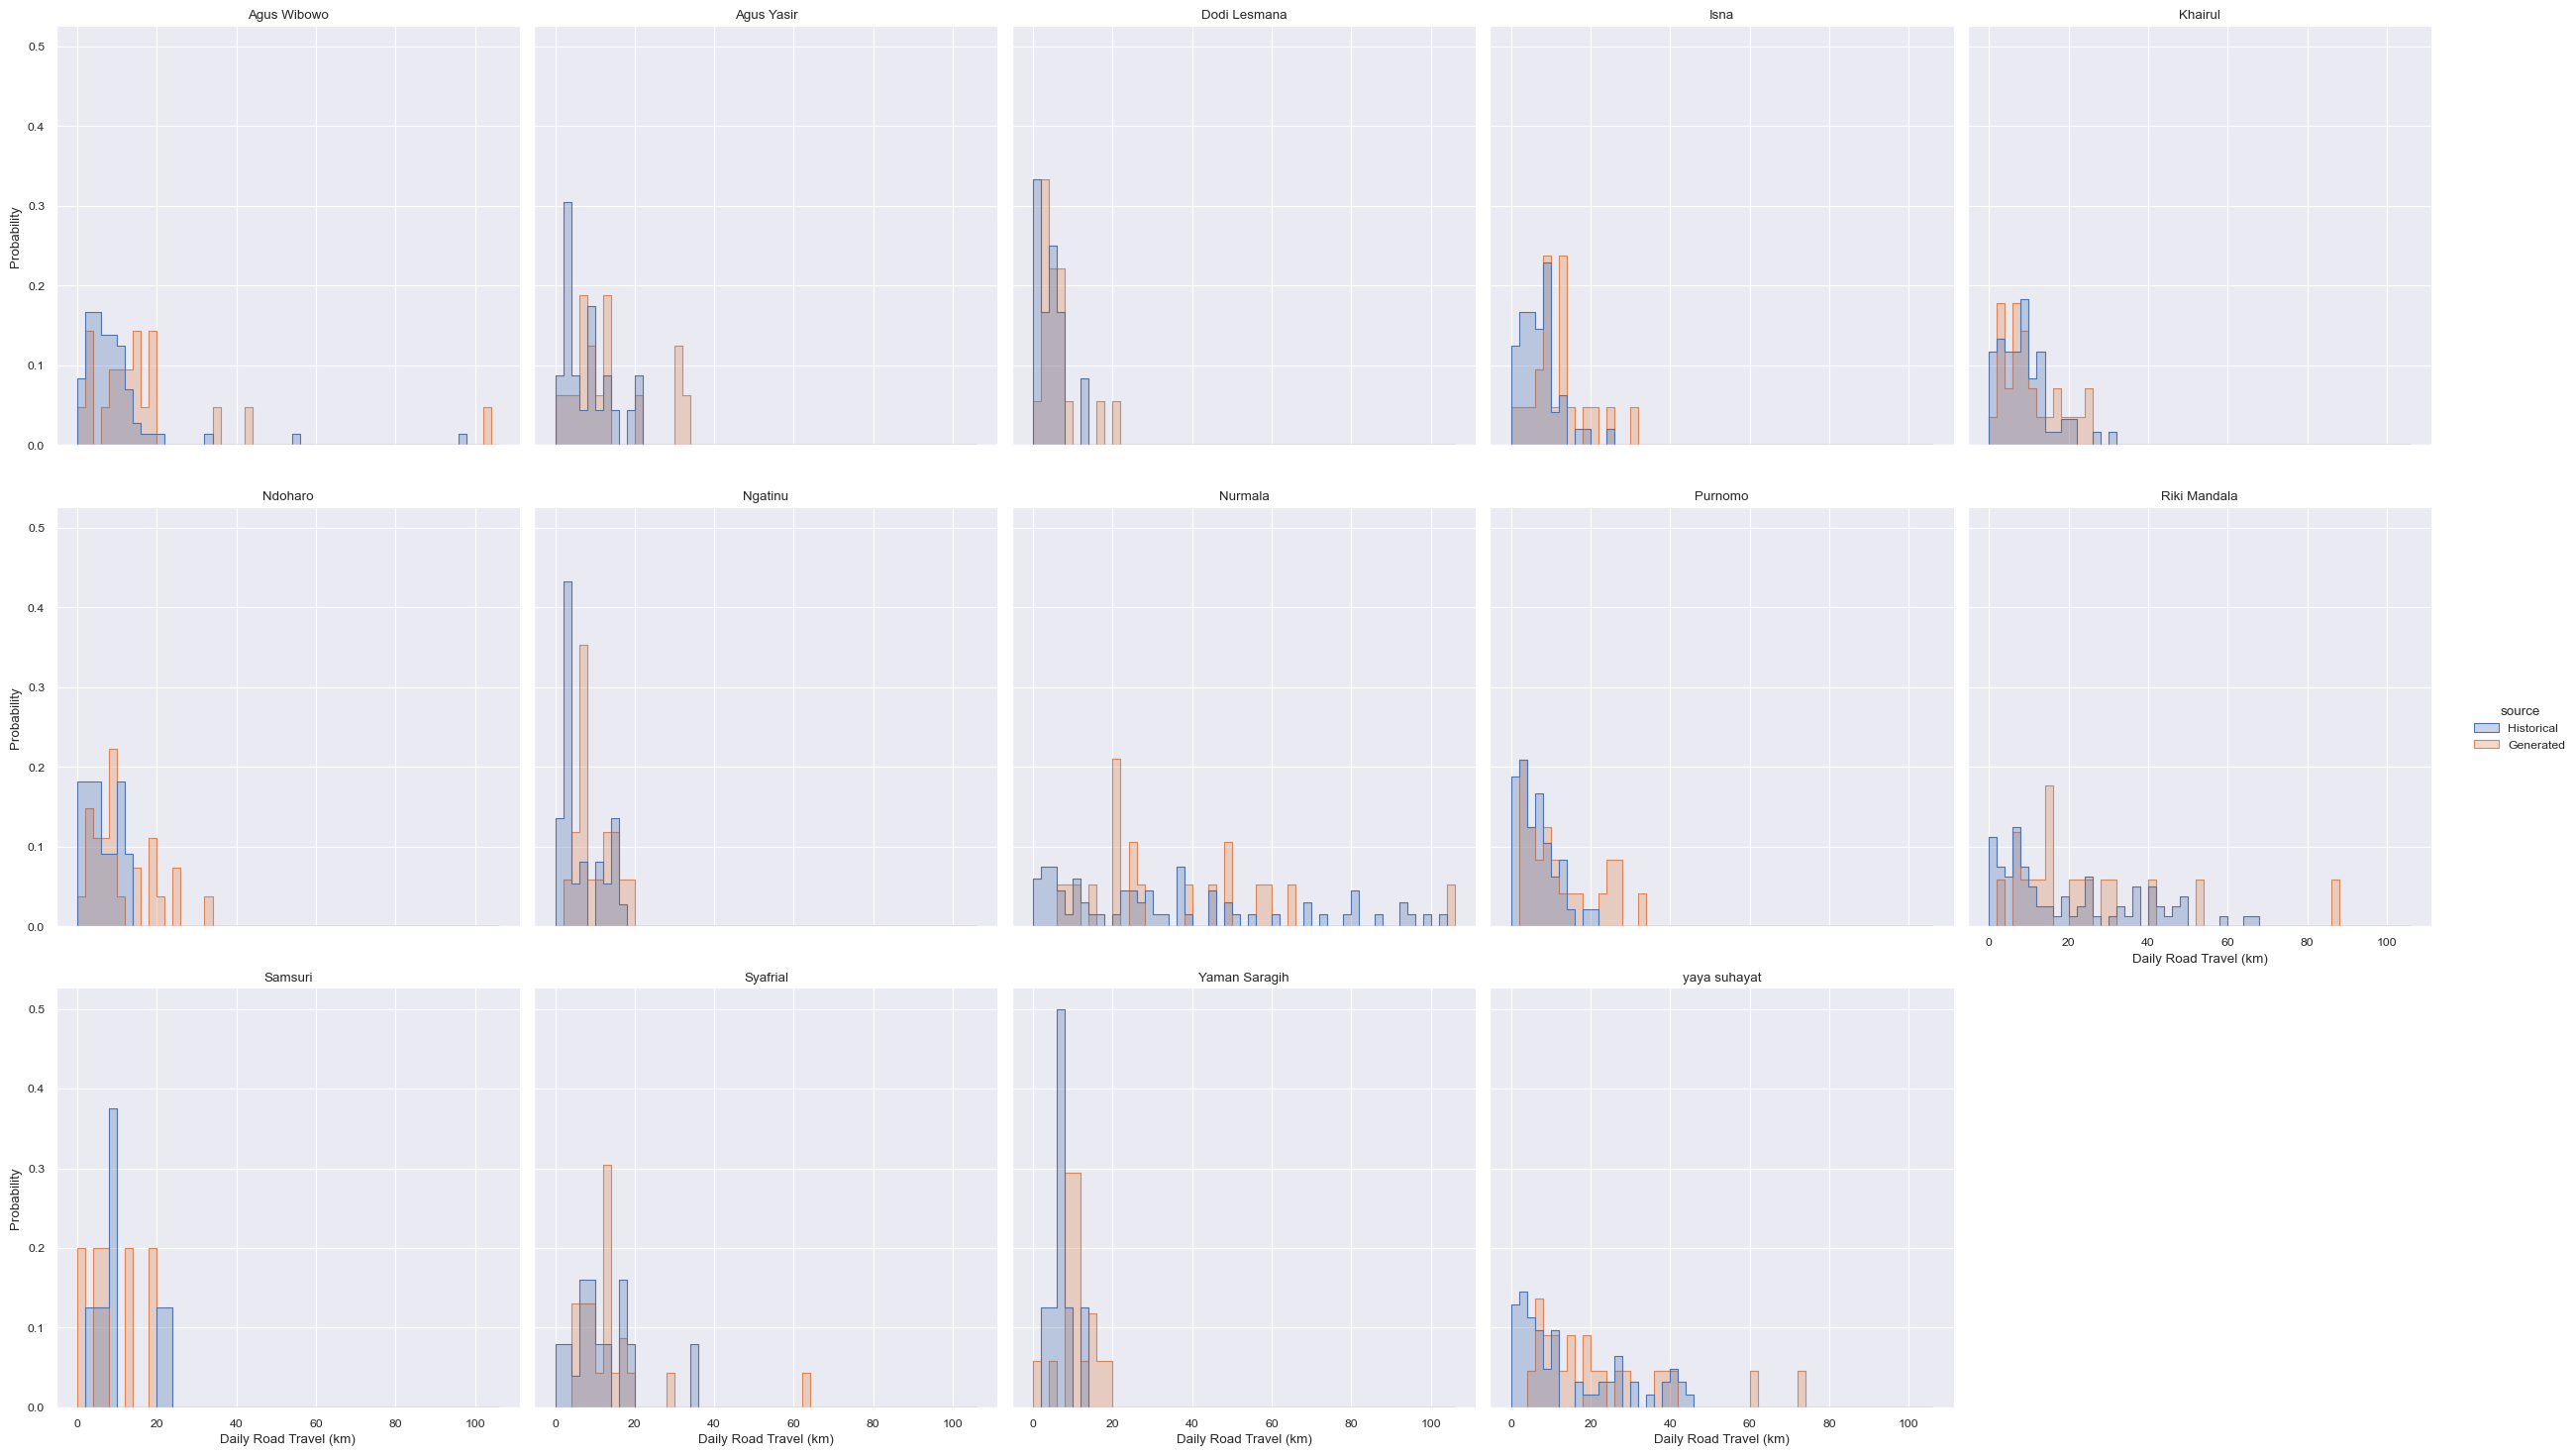

In [15]:
max_km = df_combined['km'].max()
bins = np.arange(0, max_km + 2, 2) # 2km bins for visibility

g = sns.displot(
    data=df_combined,
    x='km',
    hue='source',
    col='int_id',
    col_wrap=5,
    bins=bins,
    stat='probability',
    common_norm=False,
    element='step',
    alpha=0.3,
    facet_kws={'sharex': True, 'sharey': True}
)

# 5. Formatting
g.set_axis_labels("Daily Road Travel (km)", "Probability")
g.set_titles("{col_name}")

g.figure.subplots_adjust(hspace=0.15)

# g.figure.suptitle('Distribution of daily TSP tour length (by intermediary)', fontsize=14)
g.figure.subplots_adjust(top=0.965)

plt.show()

In [16]:
ig.sigmas

{'Dodi Lesmana': 2500,
 'Purnomo': 2500,
 'Isna': 4000,
 'Agus Wibowo': 12000,
 'Nurmala': 13500,
 'yaya suhayat': 12500,
 'Agus Yasir': 6500,
 'Ngatinu': 5500,
 'Samsuri': 13000,
 'Riki Mandala': 30500,
 'Syafrial': 9500,
 'Yaman Saragih': 3500,
 'Khairul': 4500,
 'Ndoharo': 2500}